# Análise Obesidade e IMC

Nesta análise, o foco é entender como o Índice de Massa Corporal (IMC) se associa à prevalência de diabetes e hipertensão. A ideia não é tratar o IMC como “diagnóstico”, mas usá-lo como um indicador de padrão que ajuda a identificar subgrupos com maior carga de doença.

A pergunta central é: a partir de qual faixa de IMC a prevalência de diabetes e hipertensão começa a subir de forma mais acentuada?

> **Nota metodológica:** o CDC considera IMC <18,5 como baixo peso; 18,5–<25 como peso normal; 25–<30 como sobrepeso; e ≥30 como obesidade. No BRFSS 2015, o BMI calculado foi considerado válido entre 12 e <100. Valores de IMC >60 não são automaticamente erros e serão mantidos na análise principal, com uma análise de sensibilidade até 60.

## 1. Preparação dos dados e tratamento do IMC

Começamos carregando o dataset e focando nas variáveis:

>BMI: IMC (kg/m²);

>Diabetes_binary: diabetes ou pré-diabetes (1) vs não (0);

>HighBP: pressão alta autorrelatada (1) vs não (0);

>Age: faixa etária (codificada pelo BRFSS).

Para evitar que valores extremos distorçam a leitura, aplicamos um filtro de plausibilidade para o IMC, e depois criamos faixas de IMC baseadas nos cortes clássicos de classificação nutricional.

In [12]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)


In [13]:
# Carregamento do mesmo conjunto utilizado nos demais eixos
variaveis_eixo2 = ["BMI", "Diabetes_binary", "HighBP", "Age"]
variaveis_ausentes = [v for v in variaveis_eixo2 if v not in df.columns]

if variaveis_ausentes:
    raise ValueError(f"Variáveis ausentes no dataset: {variaveis_ausentes}")

df_eixo2 = df.copy()
df_eixo2["BMI"] = pd.to_numeric(df_eixo2["BMI"], errors="coerce")

# Filtro de plausibilidade do IMC (coerente com o BRFSS 2015)
df_eixo2 = df_eixo2[df_eixo2["BMI"].between(12, 99.99, inclusive="both")].copy()

qtd_maior_60 = (df_eixo2["BMI"] > 60).sum()
pct_maior_60 = 100 * qtd_maior_60 / len(df_eixo2)

print(f"Observações válidas para IMC: {len(df_eixo2):,}")
print(f"IMC > 60: {qtd_maior_60:,} ({pct_maior_60:.3f}%)")
print("\nResumo do IMC:")
print(df_eixo2["BMI"].describe(percentiles=[.01,.05,.25,.50,.75,.95,.99]).round(2))


Observações válidas para IMC: 253,680
IMC > 60: 805 (0.317%)

Resumo do IMC:
count    253680.00
mean         28.38
std           6.61
min          12.00
1%           18.00
5%           20.00
25%          24.00
50%          27.00
75%          31.00
95%          40.00
99%          50.00
max          98.00
Name: BMI, dtype: float64


Valores de IMC > 60 foram mantidos na análise principal, pois não foram tratados automaticamente como erro. Mais adiante, fazemos uma análise de sensibilidade restringindo a amostra a IMC ≤ 60 para verificar se a presença desses extremos altera a interpretação geral.

## 2.Distribuição do IMC e criação das faixas

Para facilitar a leitura, transformamos o IMC contínuo em faixas, usando os cortes habituais:

>< 18,5 (abaixo do peso)

>18,5–24,9 (peso normal)

>25,0–29,9 (sobrepeso)

>30,0–34,9 (obesidade grau I)

>35,0–39,9 (obesidade grau II)

>≥ 40,0 (obesidade grau III)


In [4]:
bins = [-np.inf, 18.5, 25, 30, 35, 40, np.inf]
labels = [
    "<18,5",
    "18,5–24,9",
    "25,0–29,9",
    "30,0–34,9",
    "35,0–39,9",
    "≥40,0"
]

df_eixo2["Faixa_IMC"] = pd.cut(
    df_eixo2["BMI"], bins=bins, labels=labels, right=False
)

ordem = labels
distribuicao_imc = (
    df_eixo2["Faixa_IMC"]
    .value_counts(sort=False)
    .rename_axis("Faixa de IMC")
    .reset_index(name="n")
)
distribuicao_imc["%"] = 100 * distribuicao_imc["n"] / len(df_eixo2)
distribuicao_imc


,Faixa de IMC,n,%
0,"<18,5",3127,1.232655
1,"18,5–24,9",68953,27.181094
2,"25,0–29,9",93749,36.955613
3,"30,0–34,9",53451,21.070246
4,"35,0–39,9",20663,8.145301
5,"≥40,0",13737,5.415090


Essa tabela mostra quantas pessoas caem em cada faixa de IMC e qual o peso relativo de cada categoria na amostra. Isso ajuda a entender onde está concentrada a população e quais faixas têm menos dados (por exemplo, abaixo de 18,5 e acima de 40).

## 3. Prevalência de Diabetes segundo faixa de IMC

Agora olhamos para a relação entre IMC e diabetes. Para cada faixa de IMC, calculamos a porcentagem de pessoas com diabetes (ou pré-diabetes).


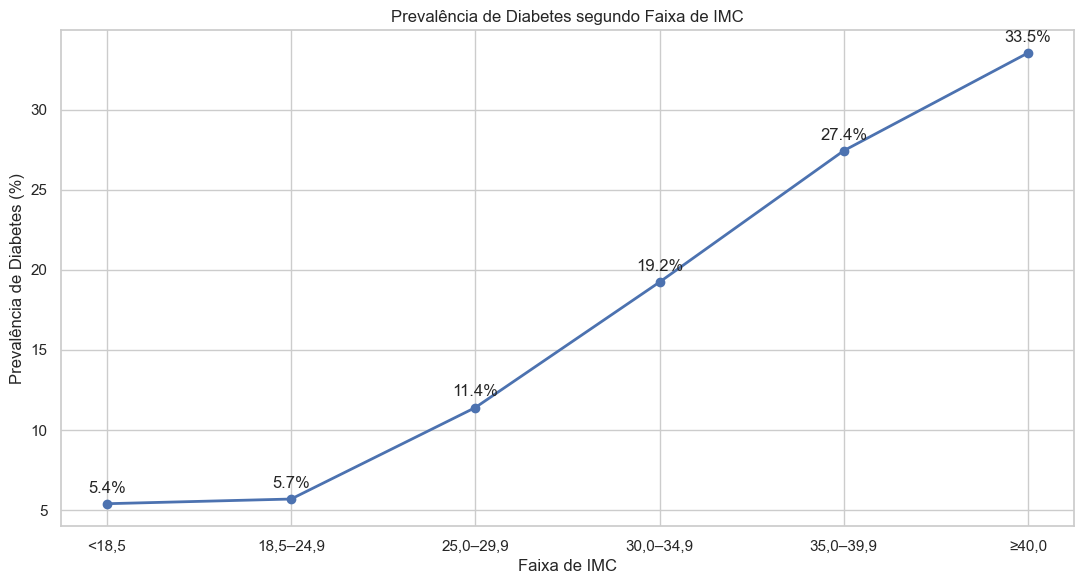

,Faixa_IMC,n,prevalencia_pct,salto_pp
0,"<18,5",3127,5.404541,NaN
1,"18,5–24,9",68953,5.696634,0.292093
2,"25,0–29,9",93749,11.404922,5.708288
3,"30,0–34,9",53451,19.234439,7.829517
4,"35,0–39,9",20663,27.435513,8.201074
5,"≥40,0",13737,33.537162,6.101650


In [5]:
prev_diabetes = (
    df_eixo2.groupby("Faixa_IMC", observed=False)["Diabetes_binary"]
    .agg(n="size", prevalencia="mean")
    .reindex(ordem)
    .reset_index()
)
prev_diabetes["prevalencia_pct"] = prev_diabetes["prevalencia"] * 100
prev_diabetes["salto_pp"] = prev_diabetes["prevalencia_pct"].diff()

plt.figure(figsize=(11, 6))
plt.plot(prev_diabetes["Faixa_IMC"].astype(str), prev_diabetes["prevalencia_pct"], marker="o", linewidth=2)
for i, row in prev_diabetes.iterrows():
    plt.annotate(f"{row['prevalencia_pct']:.1f}%", (i, row["prevalencia_pct"]), xytext=(0,8), textcoords="offset points", ha="center")
plt.xlabel("Faixa de IMC")
plt.ylabel("Prevalência de Diabetes (%)")
plt.title("Prevalência de Diabetes segundo Faixa de IMC")
plt.tight_layout()
plt.show()

prev_diabetes[["Faixa_IMC", "n", "prevalencia_pct", "salto_pp"]]


No gráfico acima, cada ponto mostra a porcentagem de pessoas com diabetes dentro de uma faixa específica de IMC. À medida que avançamos da esquerda para a direita (de IMCs mais baixos para IMCs mais altos), conseguimos enxergar como essa porcentagem se comporta.

Se a linha sobe de forma suave, isso significa que o aumento do IMC está associado a um crescimento gradual da prevalência de diabetes. Já quando a linha “dá um salto” entre duas faixas seguidas, isso indica que, naquele intervalo de IMC, a prevalência de diabetes aumenta de forma mais acentuada.



### Identificação do maior salto observado

A tabela abaixo ordena os aumentos absolutos de prevalência (em pontos percentuais) entre faixas consecutivas. Isso permite responder objetivamente em qual transição houve o maior aumento **observado**. Com esse maior aumento observado podemos ver onde o IMC passar a estar fortemente associado ao aumento da prevalência de diabetes


In [6]:
idx = prev_diabetes["salto_pp"].idxmax()

maior_salto_diabetes = pd.DataFrame({
    "Transição de IMC": [f"{prev_diabetes.loc[idx - 1, 'Faixa_IMC']} → {prev_diabetes.loc[idx, 'Faixa_IMC']}"],
    "Salto de prevalência (p.p.)": [round(prev_diabetes.loc[idx, "salto_pp"], 2)]
})

maior_salto_diabetes


,Transição de IMC,Salto de prevalência (p.p.)
0,"30,0–34,9 → 35,0–39,9",8.2


## 4. Repetição da análise com Hipertensão como desfecho

A mesma lógica é aplicada a `HighBP`: estimamos a prevalência de hipertensão em cada faixa de IMC e verificamos se o padrão de aumento acompanha o observado para diabetes.


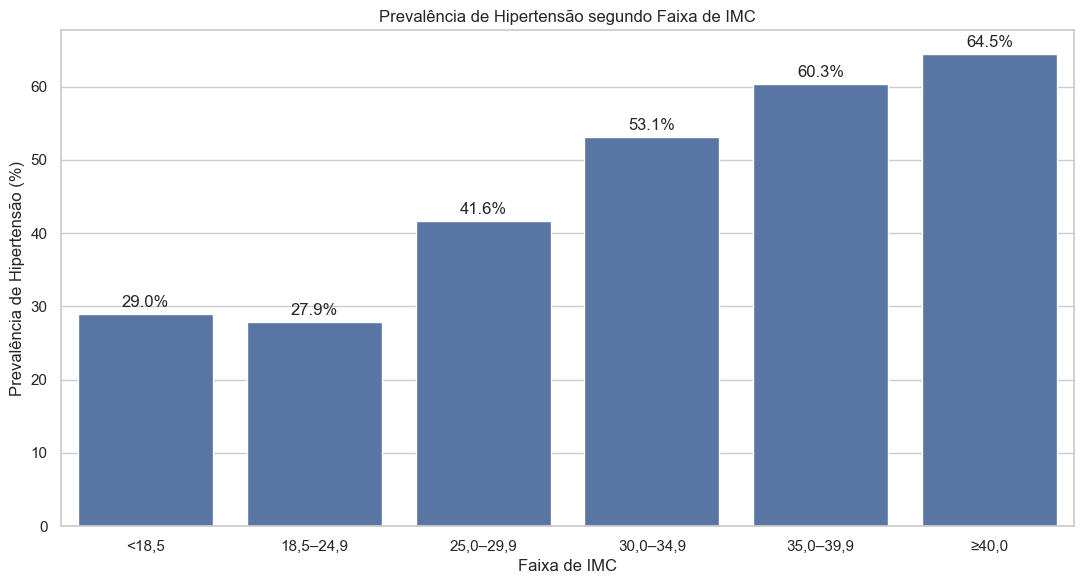

,Faixa_IMC,n,prevalencia_pct,salto_pp
0,"<18,5",3127,28.973457,NaN
1,"18,5–24,9",68953,27.891462,-1.081995
2,"25,0–29,9",93749,41.616444,13.724982
3,"30,0–34,9",53451,53.063554,11.447110
4,"35,0–39,9",20663,60.296182,7.232628
5,"≥40,0",13737,64.453665,4.157484


In [7]:
prev_hipertensao = (
    df_eixo2.groupby("Faixa_IMC", observed=False)["HighBP"]
    .agg(n="size", prevalencia="mean")
    .reindex(ordem)
    .reset_index()
)
prev_hipertensao["prevalencia_pct"] = prev_hipertensao["prevalencia"] * 100
prev_hipertensao["salto_pp"] = prev_hipertensao["prevalencia_pct"].diff()

plt.figure(figsize=(11, 6))
sns.barplot(data=prev_hipertensao, x="Faixa_IMC", y="prevalencia_pct")
for i, row in prev_hipertensao.iterrows():
    plt.text(i, row["prevalencia_pct"] + 1, f"{row['prevalencia_pct']:.1f}%", ha="center")
plt.xlabel("Faixa de IMC")
plt.ylabel("Prevalência de Hipertensão (%)")
plt.title("Prevalência de Hipertensão segundo Faixa de IMC")
plt.tight_layout()
plt.show()

prev_hipertensao[["Faixa_IMC", "n", "prevalencia_pct", "salto_pp"]]


## 5. Associação estatística por faixa de IMC (PR e OR)

Para quantificar o quanto cada faixa de IMC está associada a diabetes e hipertensão, usamos a faixa 18,5–24,9 como referência e calculamos razão de prevalências (PR) e odds ratio (OR) para as demais faixas


In [8]:
def associacao_categoria(df, exposure_col, outcome_col, categoria, referencia="18,5–24,9"):
    exp = df[exposure_col] == categoria
    ref = df[exposure_col] == referencia
    dados = df.loc[exp | ref, [exposure_col, outcome_col]].dropna()

    a = int(((dados[exposure_col] == categoria) & (dados[outcome_col] == 1)).sum())
    b = int(((dados[exposure_col] == categoria) & (dados[outcome_col] == 0)).sum())
    c = int(((dados[exposure_col] == referencia) & (dados[outcome_col] == 1)).sum())
    d = int(((dados[exposure_col] == referencia) & (dados[outcome_col] == 0)).sum())

    n1, n0 = a + b, c + d
    p1, p0 = a / n1, c / n0
    if min(a, b, c, d) == 0:
        return {
            "Categoria": categoria, "n": n1, "Prevalência (%)": p1 * 100,
            "PR": np.nan, "PR IC95%": "indisponível",
            "OR": np.nan, "OR IC95%": "indisponível", "p-valor": stats.fisher_exact([[a, b], [c, d]])[1]
        }

    pr = p1 / p0

    se_log_pr = np.sqrt((1 / a) - (1 / n1) + (1 / c) - (1 / n0))
    pr_ic = (
        np.exp(np.log(pr) - 1.96 * se_log_pr),
        np.exp(np.log(pr) + 1.96 * se_log_pr)
    )

    or_value, p_value = stats.fisher_exact([[a, b], [c, d]])
    se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
    or_ic = (
        np.exp(np.log(or_value) - 1.96 * se_log_or),
        np.exp(np.log(or_value) + 1.96 * se_log_or)
    )

    return {
        "Categoria": categoria,
        "n": n1,
        "Prevalência (%)": p1 * 100,
        "PR": pr,
        "PR IC95%": f"[{pr_ic[0]:.2f} – {pr_ic[1]:.2f}]",
        "OR": or_value,
        "OR IC95%": f"[{or_ic[0]:.2f} – {or_ic[1]:.2f}]",
        "p-valor": p_value
    }

resultados = []
for desfecho in ["Diabetes_binary", "HighBP"]:
    for categoria in labels:
        if categoria == "18,5–24,9":
            continue
        r = associacao_categoria(df_eixo2, "Faixa_IMC", desfecho, categoria)
        r["Desfecho"] = "Diabetes" if desfecho == "Diabetes_binary" else "Hipertensão"
        resultados.append(r)

tabela_associacoes = pd.DataFrame(resultados)
tabela_associacoes["PR"] = tabela_associacoes["PR"].round(2)
tabela_associacoes["OR"] = tabela_associacoes["OR"].round(2)
tabela_associacoes["p-valor"] = tabela_associacoes["p-valor"].map(lambda x: f"{x:.3e}")

tabela_associacoes[["Desfecho", "Categoria", "n", "Prevalência (%)", "PR", "PR IC95%", "OR", "OR IC95%", "p-valor"]]


,Desfecho,Categoria,n,Prevalência (%),PR,PR IC95%,OR,OR IC95%,p-valor
0,Diabetes,"<18,5",3127,5.404541,0.95,[0.82 – 1.10],0.95,[0.81 – 1.11],5.274e-01
1,Diabetes,"25,0–29,9",93749,11.404922,2.00,[1.93 – 2.07],2.13,[2.05 – 2.21],0.000e+00
2,Diabetes,"30,0–34,9",53451,19.234439,3.38,[3.26 – 3.50],3.94,[3.79 – 4.10],0.000e+00
3,Diabetes,"35,0–39,9",20663,27.435513,4.82,[4.64 – 5.00],6.26,[5.99 – 6.54],0.000e+00
4,Diabetes,"≥40,0",13737,33.537162,5.89,[5.67 – 6.12],8.35,[7.96 – 8.76],0.000e+00
5,Hipertensão,"<18,5",3127,28.973457,1.04,[0.98 – 1.10],1.05,[0.97 – 1.14],1.922e-01
6,Hipertensão,"25,0–29,9",93749,41.616444,1.49,[1.47 – 1.51],1.84,[1.80 – 1.88],0.000e+00
7,Hipertensão,"30,0–34,9",53451,53.063554,1.90,[1.88 – 1.93],2.92,[2.85 – 2.99],0.000e+00
8,Hipertensão,"35,0–39,9",20663,60.296182,2.16,[2.13 – 2.20],3.93,[3.80 – 4.06],0.000e+00
9,Hipertensão,"≥40,0",13737,64.453665,2.31,[2.27 – 2.35],4.69,[4.51 – 4.87],0.000e+00


Como ler essa tabela:

>Cada linha compara uma faixa de IMC com a faixa de referência (18,5–24,9).

>PR > 1 indica maior prevalência do desfecho naquela faixa.

>OR > 1 indica maior chance do desfecho.

>IC95% que não inclui 1 e p-valor pequeno sugerem associação estatisticamente significativa.

## 6. Visão mais detalhada do IMC

Para enxergar a relação de forma mais fina, criamos faixas de IMC em intervalos menores (de 5 em 5 unidades, até ≥ 60) e plotamos diabetes e hipertensão juntas.

In [9]:
bins_finos = [12, 18.5, 25, 30, 35, 40, 45, 50, 55, 60, 100]
labels_finos = [
    "12–18,4", "18,5–24,9", "25–29,9", "30–34,9", "35–39,9",
    "40–44,9", "45–49,9", "50–54,9", "55–59,9", "≥60"
]

df_eixo2["Faixa_IMC_fina"] = pd.cut(
    df_eixo2["BMI"], bins=bins_finos, labels=labels_finos, right=False
)

resumo_fino = (
    df_eixo2.groupby("Faixa_IMC_fina", observed=False)
    .agg(n=("BMI", "size"),
         diabetes=("Diabetes_binary", "mean"),
         hipertensao=("HighBP", "mean"))
    .reindex(labels_finos)
    .reset_index()
)
resumo_fino["Diabetes (%)"] = resumo_fino["diabetes"] * 100
resumo_fino["Hipertensão (%)"] = resumo_fino["hipertensao"] * 100
resumo_fino["Salto Diabetes (pp)"] = resumo_fino["Diabetes (%)"].diff()
resumo_fino["Salto Hipertensão (pp)"] = resumo_fino["Hipertensão (%)"].diff()

resumo_fino


,Faixa_IMC_fina,n,diabetes,hipertensao,Diabetes (%),Hipertensão (%),Salto Diabetes (pp),Salto Hipertensão (pp)
0,"12–18,4",3127,0.054045,0.289735,5.404541,28.973457,NaN,NaN
1,"18,5–24,9",68953,0.056966,0.278915,5.696634,27.891462,0.292093,-1.081995
2,"25–29,9",93749,0.114049,0.416164,11.404922,41.616444,5.708288,13.724982
3,"30–34,9",53451,0.192344,0.530636,19.234439,53.063554,7.829517,11.447110
4,"35–39,9",20663,0.274355,0.602962,27.435513,60.296182,8.201074,7.232628
5,"40–44,9",8099,0.322385,0.641561,32.238548,64.156069,4.803035,3.859887
6,"45–49,9",3091,0.370430,0.664510,37.043028,66.450987,4.804480,2.294918
7,"50–54,9",1190,0.390756,0.681513,39.075630,68.151261,2.032602,1.700274
8,"55–59,9",489,0.388548,0.725971,38.854806,72.597137,-0.220825,4.445877
9,≥60,868,0.225806,0.504608,22.580645,50.460829,-16.274161,-22.136308


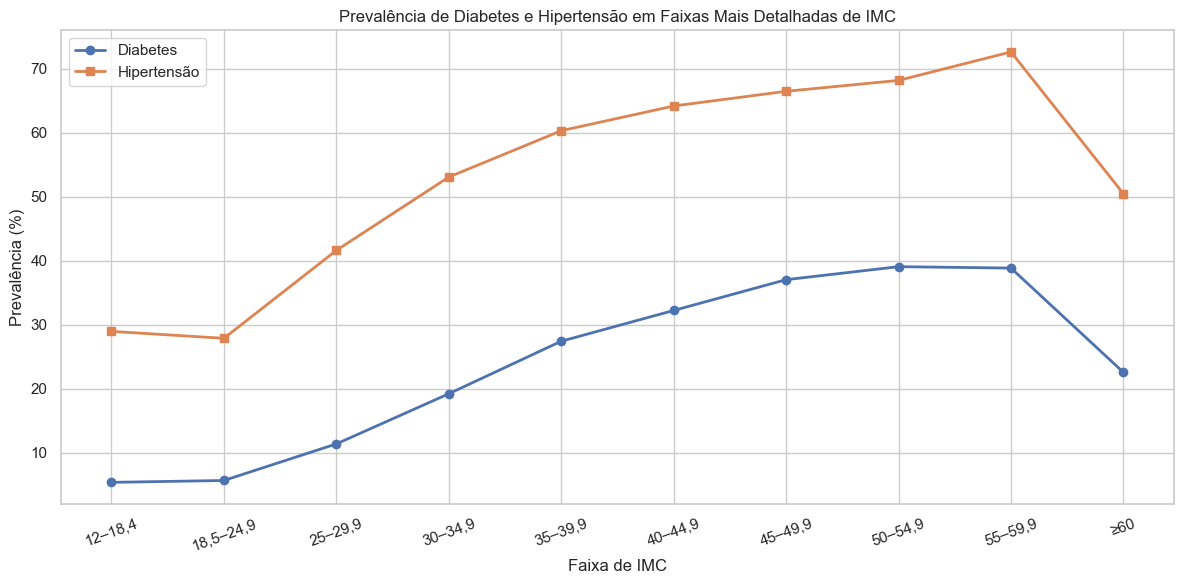

In [10]:
plt.figure(figsize=(12, 6))
x = np.arange(len(resumo_fino))
plt.plot(x, resumo_fino["Diabetes (%)"], marker="o", linewidth=2, label="Diabetes")
plt.plot(x, resumo_fino["Hipertensão (%)"], marker="s", linewidth=2, label="Hipertensão")
plt.xticks(x, labels_finos, rotation=20)
plt.xlabel("Faixa de IMC")
plt.ylabel("Prevalência (%)")
plt.title("Prevalência de Diabetes e Hipertensão em Faixas Mais Detalhadas de IMC")
plt.legend()
plt.tight_layout()
plt.show()



Esse gráfico permite ver se diabetes e hipertensão “sobem juntas” com o IMC ou se uma delas tem um comportamento diferente em determinadas faixas.

## 7. Análise de sensibilidade: excluindo IMC >60

A análise principal mantém os valores acima de 60. Aqui verificamos se a conclusão geral muda quando esses valores são retirados.

A comparação é feita para as mesmas faixas finas. Se as curvas permanecerem semelhantes, isso reforça que os extremos não estão determinando sozinhos o padrão observado.


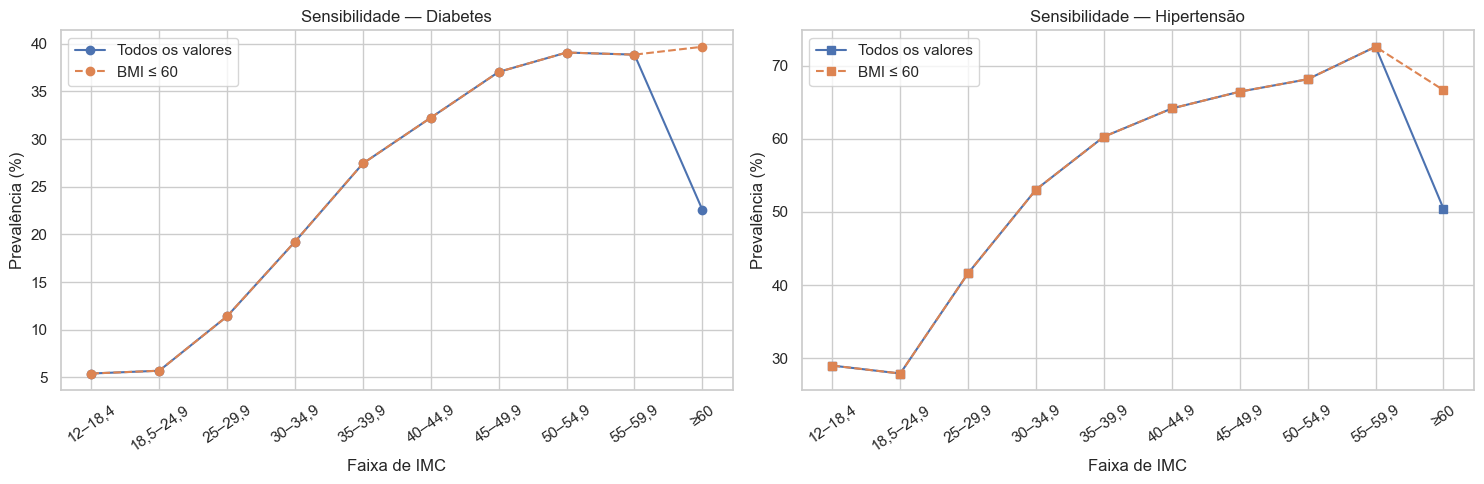

,Faixa_IMC_fina,Diabetes — todos,Hipertensão — todos,Diabetes — BMI ≤60,Hipertensão — BMI ≤60
0,"12–18,4",5.404541,28.973457,5.404541,28.973457
1,"18,5–24,9",5.696634,27.891462,5.696634,27.891462
2,"25–29,9",11.404922,41.616444,11.404922,41.616444
3,"30–34,9",19.234439,53.063554,19.234439,53.063554
4,"35–39,9",27.435513,60.296182,27.435513,60.296182
5,"40–44,9",32.238548,64.156069,32.238548,64.156069
6,"45–49,9",37.043028,66.450987,37.043028,66.450987
7,"50–54,9",39.075630,68.151261,39.075630,68.151261
8,"55–59,9",38.854806,72.597137,38.854806,72.597137
9,≥60,22.580645,50.460829,39.682540,66.666667


In [11]:
df_sem_extremos = df_eixo2[df_eixo2["BMI"] <= 60].copy()

resumo_sens = (
    df_sem_extremos.groupby("Faixa_IMC_fina", observed=False)
    .agg(n=("BMI", "size"),
         diabetes=("Diabetes_binary", "mean"),
         hipertensao=("HighBP", "mean"))
    .reindex(labels_finos)
    .reset_index()
)
resumo_sens["Diabetes (%)"] = resumo_sens["diabetes"] * 100
resumo_sens["Hipertensão (%)"] = resumo_sens["hipertensao"] * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(labels_finos))

axes[0].plot(x, resumo_fino["Diabetes (%)"], marker="o", label="Todos os valores")
axes[0].plot(x, resumo_sens["Diabetes (%)"], marker="o", linestyle="--", label="BMI ≤ 60")
axes[0].set_title("Sensibilidade — Diabetes")
axes[0].set_xlabel("Faixa de IMC")
axes[0].set_ylabel("Prevalência (%)")
axes[0].set_xticks(x, labels_finos, rotation=35)
axes[0].legend()

axes[1].plot(x, resumo_fino["Hipertensão (%)"], marker="s", label="Todos os valores")
axes[1].plot(x, resumo_sens["Hipertensão (%)"], marker="s", linestyle="--", label="BMI ≤ 60")
axes[1].set_title("Sensibilidade — Hipertensão")
axes[1].set_xlabel("Faixa de IMC")
axes[1].set_ylabel("Prevalência (%)")
axes[1].set_xticks(x, labels_finos, rotation=35)
axes[1].legend()

plt.tight_layout()
plt.show()

comparacao = resumo_fino[["Faixa_IMC_fina", "Diabetes (%)", "Hipertensão (%)"]].copy()
comparacao = comparacao.rename(columns={"Diabetes (%)":"Diabetes — todos", "Hipertensão (%)":"Hipertensão — todos"})
comparacao["Diabetes — BMI ≤60"] = resumo_sens["Diabetes (%)"]
comparacao["Hipertensão — BMI ≤60"] = resumo_sens["Hipertensão (%)"]
comparacao


Os gráficos acima comparam duas versões da mesma análise: uma incluindo todos os valores de IMC e outra restringindo a amostra a IMC ≤ 60. Cada par de curvas (uma contínua e outra tracejada) representa a prevalência de diabetes ou hipertensão ao longo das faixas de IMC, sob essas duas condições.

Se as curvas “todos os valores” e “IMC ≤ 60” seguirem praticamente o mesmo caminho — com formatos, inclinações e níveis de prevalência muito parecidos —, isso indica que os valores extremos de IMC (> 60) não estão distorcendo a leitura geral. Em outras palavras, a relação entre IMC e prevalência de diabetes/hipertensão é robusta: o padrão observado não depende da presença desses casos mais raros.

# 8. Conclusões

A análise da relação entre o Índice de Massa Corporal (IMC) e as comorbidades crônicas revelou que, embora o peso seja um fator de risco universal, o comportamento e a "escalada" do diabetes e da hipertensão ocorrem em ritmos e limiares muito distintos.

>O Alerta Precoce da Hipertensão: O sistema cardiovascular reage muito cedo ao ganho de peso. O maior salto absoluto na prevalência de hipertensão ocorre logo na transição do peso normal para o Sobrepeso (IMC 25,0–29,9), registrando um aumento massivo de 13,72 pontos percentuais. Isso indica que a prevenção primária da hipertensão exige intervenção imediata antes mesmo de o paciente atingir a obesidade. 

>O Ponto de Ruptura do Diabetes: Em contraste com a hipertensão, a prevalência de diabetes sofre o seu crescimento mais agudo em estágios mais avançados de acúmulo de peso. O maior salto de risco (8,20 pontos percentuais) foi registrado na entrada da faixa de Obesidade Grau II (IMC 35,0–39,9). Essa faixa representa a zona de vulnerabilidade crítica onde a resistência à insulina se converte em diagnóstico com maior velocidade.

Em síntese, o eixo reforça que o aumento do IMC está associado a uma maior prevalência de diabetes e hipertensão, com um padrão progressivo e robusto, mesmo quando valores extremos de IMC são excluídos.